# Survey ↔ Vote Matching Pipeline

End-to-end pipeline: **embed → match → enrich dates → simplify**

In [19]:
from pathlib import Path
from eu_survey_correlation.embeddings.date_utils import (
    build_survey_date_mapping,
    resolve_survey_date,
)

import pandas as pd

# ── Config ────────────────────────────────────────────────────────────
DATA_DIR = Path("data")

SURVEY_CSV = DATA_DIR / "surveys" / "michlou_survey_tri.csv"
VOTE_SUMMARIES_CSV = DATA_DIR / "votes" / "vote_summaries.csv"
VOTES_CSV = DATA_DIR / "votes" / "votes.csv"

EMBEDDING_CACHE = DATA_DIR / "cache" / "embeddings.parquet"

SIMPLIFIER_CACHE = DATA_DIR / "cache" / "simplified_text.json"
OUTPUT_CSV = DATA_DIR / "matches" / "simplified_michlou_survey_vote_matches_clean.csv"

TOP_K = 3
THRESHOLD = 0.0

## 1. Load data

In [20]:
surveys = (
    pd.read_csv(SURVEY_CSV)
    .dropna(subset=["question_en"])
    .drop_duplicates(subset=["question_en"])
)
vote_summaries = (
    pd.read_csv(VOTE_SUMMARIES_CSV)
    .dropna(subset=["summary"])
    .drop_duplicates(subset=["vote_id"])
)
print(f"Surveys: {len(surveys)} | Vote summaries: {len(vote_summaries)}")

Surveys: 115 | Vote summaries: 2205


## 2. Simplify questions and votes

In [21]:
from eu_survey_correlation.simplifier import Simplifier

simplifier = Simplifier(cache_path=SIMPLIFIER_CACHE)

# Skip if question_clean already present in input CSV
surveys = simplifier.simplify_dataframe(
    surveys,
    text_column="question_en",
    output_column="question_clean",
    prompt_template=Simplifier.SURVEY_QUESTION_PROMPT,
    save_path=SURVEY_CSV,
)
print(len(surveys))
surveys = surveys.drop_duplicates(subset=["question_clean"])
print(len(surveys))

2026-03-08 12:32:16.069 | INFO     | eu_survey_correlation.simplifier:__init__:74 - Loaded 1726 cached simplifications from data/cache/simplified_text.json
2026-03-08 12:32:16.072 | INFO     | eu_survey_correlation.simplifier:simplify_dataframe:179 - Cache hit for 115/115 rows
2026-03-08 12:32:16.072 | SUCCESS  | eu_survey_correlation.simplifier:simplify_dataframe:182 - All 115 rows served from cache


115
107


In [23]:
DISTRIBUTIONS_META = DATA_DIR / "surveys" / "distributions_metadata.json"

date_mapping = build_survey_date_mapping(DISTRIBUTIONS_META)
surveys["survey_date"] = surveys["file_name"].apply(
    lambda f: resolve_survey_date(str(f), date_mapping)
)

In [24]:
# Skip if question_clean already present in input CSV
vote_summaries = simplifier.simplify_dataframe(
    vote_summaries,
    text_column="summary",
    output_column="summary_clean",
    prompt_template=Simplifier.VOTE_SUMMARY_PROMPT,
    save_path=VOTE_SUMMARIES_CSV,
)
print(len(vote_summaries))
vote_summaries = vote_summaries.drop_duplicates(subset=["summary_clean"])
print(len(vote_summaries))

2026-03-08 12:32:27.906 | INFO     | eu_survey_correlation.simplifier:simplify_dataframe:179 - Cache hit for 2205/2205 rows
2026-03-08 12:32:27.908 | SUCCESS  | eu_survey_correlation.simplifier:simplify_dataframe:182 - All 2205 rows served from cache


2205
1611


In [25]:
votes_full = pd.read_csv(VOTES_CSV)
votes_full["vote_date"] = pd.to_datetime(
    votes_full["timestamp"], format="%d/%m/%Y %H:%M", errors="coerce"
)
vote_date_map = dict(zip(votes_full["id"], votes_full["vote_date"]))

vote_summaries["vote_date"] = vote_summaries["vote_id"].map(vote_date_map)

## 2. Embed surveys & votes

In [26]:
from eu_survey_correlation.embeddings import Embedder

embedder = Embedder(cache_path=EMBEDDING_CACHE)

survey_emb_df = embedder.embed_dataframe(surveys, text_column="question_clean")
vote_emb_df = embedder.embed_dataframe(vote_summaries, text_column="summary_clean")
print(
    f"Survey embeddings: {survey_emb_df.shape} | Vote embeddings: {vote_emb_df.shape}"
)

2026-03-08 12:32:32.978 | INFO     | eu_survey_correlation.embeddings.embedder:__init__:33 - Loading SentenceTransformer model 'all-MiniLM-L6-v2'...
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1588.65it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 12:32:35.480 | SUCCESS  | eu_survey_correlation.embeddings.embedder:__init__:35 - Model 'all-MiniLM-L6-v2' loaded (dim=384)
2026-03-08 12:32:35.517 | INFO     | eu_survey_correlation.embeddings.embedder:__init__:41 - Loaded embedding cache: 9612 rows from data/cache/embeddings.parquet
2026-03-08 12:32:35.560 | INFO     | eu_survey_correlation.embeddings.embedder:embed_dataframe:99 

Survey embeddings: (107, 391) | Vote embeddings: (1611, 388)


## 4. Match pairs

In [10]:
from eu_survey_correlation.embeddings import PairMatcher

matcher = PairMatcher(survey_embeddings=survey_emb_df, vote_embeddings=vote_emb_df)
matches = matcher.match(top_k=TOP_K, threshold=THRESHOLD)
print(f"Raw matches: {len(matches)}")

2026-03-08 12:24:09.544 | SUCCESS  | eu_survey_correlation.embeddings.pair_matcher:__init__:48 - Loaded 107 survey and 1611 vote embeddings (dim=384)
2026-03-08 12:24:09.545 | INFO     | eu_survey_correlation.embeddings.pair_matcher:match:65 - Computing matches (top_k=3, threshold=0.0, batch_size=256)...
Computing matches: 100%|██████████| 1/1 [00:00<00:00, 18.17it/s]
2026-03-08 12:24:09.604 | INFO     | eu_survey_correlation.embeddings.pair_matcher:match:113 - Found 321 matches above threshold 0.0


Raw matches: 321


## 7. Save results

In [12]:
# Select and rename final columns
output_cols = [
    "sheet_id",
    "question_clean",
    "question_en",
    "file_name",
    "survey_date",
    "vote_id",
    "summary",
    "summary_clean",
    "vote_date",
    "similarity_score",
    "time_delta",
]
# Keep only columns that exist
output_cols = [c for c in output_cols if c in matches.columns]
result = matches[output_cols].sort_values("similarity_score", ascending=False)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
result.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(result)} matches → {OUTPUT_CSV}")

Saved 321 matches → data/matches/simplified_michlou_survey_vote_matches_clean.csv


## 8. Explore results

Total matches: 321
Unique questions: 93
Unique votes: 184

Similarity stats:
count    321.000000
mean       0.509814
std        0.096519
min        0.269490
25%        0.435461
50%        0.541994
75%        0.579365
max        0.693864
Name: similarity_score, dtype: float64

Time delta stats (days):
count     303.000000
mean      236.346535
std       800.220004
min     -1694.000000
25%      -327.500000
50%       202.000000
75%       811.000000
max      2247.000000
Name: time_delta, dtype: float64


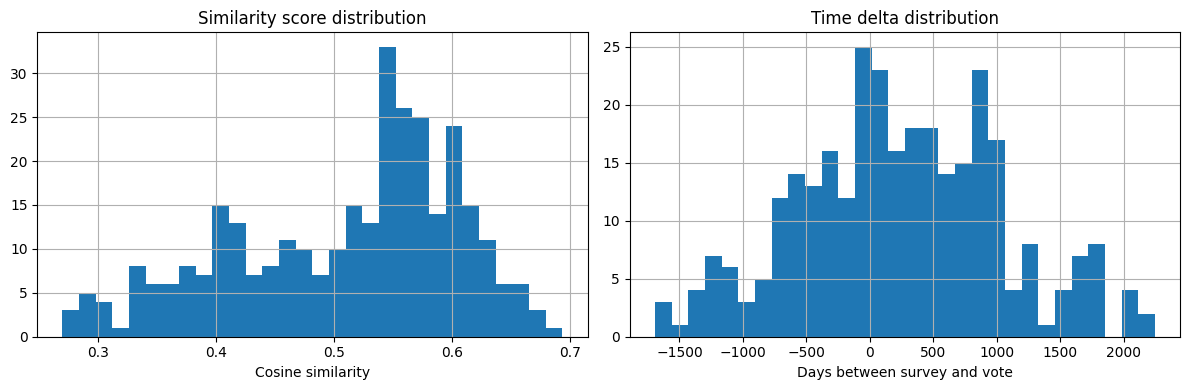

In [13]:
import matplotlib.pyplot as plt

print(f"Total matches: {len(result)}")
print(f"Unique questions: {result['sheet_id'].nunique()}")
print(f"Unique votes: {result['vote_id'].nunique()}")
print(f"\nSimilarity stats:\n{result['similarity_score'].describe()}")
print(f"\nTime delta stats (days):\n{result['time_delta'].describe()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
result["similarity_score"].hist(bins=30, ax=axes[0])
axes[0].set_title("Similarity score distribution")
axes[0].set_xlabel("Cosine similarity")

result["time_delta"].hist(bins=30, ax=axes[1])
axes[1].set_title("Time delta distribution")
axes[1].set_xlabel("Days between survey and vote")
plt.tight_layout()
plt.show()

In [14]:
# Top matches
for _, row in result.head(10).iterrows():
    q = row.get("question_clean", row.get("question_en", ""))
    v = row.get("summary_clean", row.get("summary", ""))
    print(f"Survey:  {q}")
    print(f"Vote:    {v}")
    print(
        f"Score:   {row['similarity_score']:.3f}  |  Δt: {row.get('time_delta', '?')} days"
    )
    print()

Survey:  Do you totally agree, tend to agree, tend to disagree, or totally disagree that each EU Member State should have a minimum wage for workers?
Vote:    The European Parliament voted to support minimum wages ensuring a decent living standard, while respecting national wage-setting practices. Strengthening collective bargaining is proposed in countries where it covers less than 80% of workers, with the right to redress for workers, their representatives, and union members if rules are violated.
Score:   0.694  |  Δt: -180.0 days

Survey:  What should the European Union prioritize in its response to the Coronavirus pandemic (max. 3 answers)?
Vote:    The European Parliament passed a resolution (526-105) to strengthen the EU's public health strategy post-COVID-19, highlighting the need for stronger tools to address cross-border health emergencies due to the interconnected nature of novel infectious diseases.
Score:   0.680  |  Δt: -388.0 days

Survey:  What should the European Union